## RandomForest の実装Notebook

In [32]:
import pandas as pd#pandasのインポート
import datetime#元データの日付処理のためにインポート
from sklearn.model_selection import train_test_split#データ分割用
from sklearn.ensemble import RandomForestClassifier#ランダムフォレスト
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve, auc

In [17]:
def RandomForestprediction(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=5)#ランダムフォレストモデルの定義
    model.fit(X_train, y_train)#モデルの学習

    predictions = model.predict(X_test)#テストデータに対する予測を実行
    probs = model.predict_proba(X_test)[:, 1]


    accuracy = model.score(X_test, y_test)#モデルの精度評価
    
    feature_importances = model.feature_importances_#特徴量の重要度を取得

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)


    roc_auc = roc_auc_score(y_test, probs)
    precision_points, recall_points, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall_points, precision_points)

    print("Details")
    details = [{'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'ROC AUC': roc_auc,
                'PR AUC': pr_auc}]
    print(pd.DataFrame(details))
    print(classification_report(y_test, predict))
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return pd.DataFrame(details), feature_importances

    

#### 調整する部分の意味を以下に記す：


In [ ]:
# 3. パラメーター（引数）の詳細
# RandomForestClassifierには多くの調整項目（ハイパーパラメーター）があります。大きく分けて「個々の木に関するもの」と「森全体に関するもの」があります。

# ① 個々の木の構成に関するもの
# criterion: 分割の品質を測定する指標。

# "gini" (デフォルト): ジニ不純度。

# "entropy" または "log_loss": 情報利得（エントロピー）。


# max_depth: 木の最大深さ。

# None (デフォルト): 全てのノードが純粋になるか、min_samples_split未満になるまで成長します。過学習を防ぐために数値を指定するのが一般的です。


# min_samples_split: ノードを分割するために必要な最小サンプル数。

# デフォルトは 2。大きくすると、より保守的な（単純な）モデルになります。


# min_samples_leaf: 葉ノード（末端）に必要な最小サンプル数。

# デフォルトは 1。これも大きくすると過学習を抑えられます。


# max_features: 最適な分割を探す際に考慮する特徴量の数。

# "sqrt" (デフォルト): sqrt(n_features)。

# "log2": log2(n_features)。

# None: 全ての特徴量を使用。



# max_leaf_nodes: 葉ノードの最大数。

# min_impurity_decrease: 分割によってこの数値以上の不純度の減少が見込まれる場合にノードを分割します。

# ccp_alpha: コスト複雑度プルーニング（剪定）のためのパラメーター。過学習を防ぐための高度な手法です。


# ==========================================================================================    


# ② 森全体・サンプリングに関するもの
# n_estimators: 作成する決定木の数。

# デフォルトは 100。基本的には多いほど精度が安定しますが、計算時間が増えます。

# bootstrap: データの構築にブートストラップサンプル（重複を許す再抽出）を使用するかどうか。

# デフォルトは True。

# oob_score: アウト・オブ・バッグ（Out-of-Bag）推定を使用して汎化精度を計測するかどうか。

# Trueにすると、テストデータを使わずに精度の目安を確認できます。

# max_samples: bootstrap=True の場合に、各決定木の学習に使用するサンプル数。





# ③ 計算・その他
# n_jobs: 並列処理するジョブの数。

# -1 にすると、PCの全てのプロセッサを使用します（高速化）。

# random_state: 乱数シード。結果の再現性を確保するために重要です。

# class_weight: クラスごとの重み付け。

# 不均衡データ（例：Aクラスが99%、Bクラスが1%）の場合に "balanced" を指定すると効果的です。

# warm_start: True にすると、以前の呼び出しの結果を再利用して、森に木を追加できます。






# 4. 主要な属性（モデル学習後に確認できるもの）
# 学習した後に clf.feature_importances_ のようにアクセスできます。

# feature_importances_: 各特徴量の重要度。どの変数が予測に寄与したかを分析する際に非常に重要です。

# estimators_: 学習された個々の決定木のリスト。

# classes_: 分類されたクラスのラベル。

# n_features_in_: 学習時に使用された特徴量の数。

# oob_score_: oob_score=True の場合に計算される、学習データのみを用いた精度スコア。






# 5. 主要なメソッド
# fit(X, y): モデルを学習させます。

# predict(X): クラスを予測します。

# predict_proba(X): 各クラスに属する確率を返します（例：[0.1, 0.9]）。

# score(X, y): 指定したテストデータでの平均精度（Accuracy）を返します。

# apply(X): 各サンプルが各木のどの葉ノードに分類されたかのインデックスを返します。

# get_params() / set_params(): ハイパーパラメーターの取得・設定。




# 6. 実践的なアドバイス（チューニングの優先順位）
# 全てのパラメーターを調整するのは大変です。精度向上のためにまず調整すべきは以下の3点です。

# n_estimators: まずは100程度から始め、余裕があれば増やす（通常、多いほど良い）。

# max_depth: 過学習している（訓練データの精度が高く、テストデータの精度が低い）場合は、この数値を小さくして木を浅くします。

# max_features: 個々の木が多様性を持つように調整します。デフォルトの "sqrt" が一般的に最適ですが、特徴量が非常に少ない場合は None を試す価値があります。

# さらに、不均衡データを扱う場合は class_weight="balanced" を設定することを忘れないようにしてください。

#### Logit のDataFrameを例に実装してみる；　疫学データなどでCategory変数がある場合はEncodingする必要があるか

In [ ]:
df = pd.read_csv('/Users/yoshizawakazuki/Desktop/Datasets/Logit_data.csv')

/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_69322/163632400.py:1: DtypeWarning: Columns (39,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/yoshizawakazuki/Kazuki_module/MaschineLearning/Logit_data.csv')


In [10]:
df

,Unnamed: 0,key,y,x,label,pred,class_0,class_1,class_2,class_3,...,ignore_error_flag,error,combination,difference,type,ratio,ratio_type,shape,difference_shape,Target
0,0,frankfurt_000001_066832,0,0,255,2,-1.434775,-2.083891,5.882963,-0.671847,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,frankfurt_000001_066832,0,1,255,2,-1.434775,-2.083891,5.882963,-0.671847,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,frankfurt_000001_066832,0,2,255,2,-1.464877,-2.085818,5.967637,-0.636951,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
3,3,frankfurt_000001_066832,0,3,255,2,-1.525080,-2.089673,6.136985,-0.567160,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
4,4,frankfurt_000001_066832,0,4,255,2,-1.585284,-2.093527,6.306334,-0.497369,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2097147,2097147,frankfurt_000001_066832,1023,2043,255,0,3.679024,1.801963,3.178625,0.278655,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2097148,2097148,frankfurt_000001_066832,1023,2044,255,0,3.551764,1.768597,3.167632,0.275143,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2097149,2097149,frankfurt_000001_066832,1023,2045,255,0,3.424504,1.735231,3.156638,0.271630,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2097150,2097150,frankfurt_000001_066832,1023,2046,255,0,3.360874,1.718548,3.151142,0.269874,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1


In [14]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Target: Correct or Incorrect
df['Target']= np.where(df['label']!=df['pred'],1,0)

data = df[df['label']!=255]
data





,Unnamed: 0,key,y,x,label,pred,class_0,class_1,class_2,class_3,...,ignore_error_flag,error,combination,difference,type,ratio,ratio_type,shape,difference_shape,Target
10258,10258,frankfurt_000001_066832,5,18,2,2,-0.534489,-0.812796,6.592903,-0.047219,...,False,False,2-2,2.757286,Correct,0.581780,Correct,NaN,NaN,0
10259,10259,frankfurt_000001_066832,5,19,2,2,-0.477625,-0.741803,6.600158,-0.059776,...,False,False,2-2,2.769392,Correct,0.580405,Correct,NaN,NaN,0
10260,10260,frankfurt_000001_066832,5,20,2,2,-0.420761,-0.670811,6.607413,-0.072333,...,False,False,2-2,2.781497,Correct,0.579034,Correct,NaN,NaN,0
10261,10261,frankfurt_000001_066832,5,21,2,2,-0.363896,-0.599819,6.614668,-0.084890,...,False,False,2-2,2.793603,Correct,0.577665,Correct,NaN,NaN,0
10262,10262,frankfurt_000001_066832,5,22,2,2,-0.320220,-0.548411,6.621589,-0.101053,...,False,False,2-2,2.804602,Correct,0.576446,Correct,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003257,2003257,frankfurt_000001_066832,978,313,0,0,5.357340,0.685261,0.429156,-0.950583,...,False,False,0-0,4.672080,Correct,0.127911,Correct,NaN,NaN,0
2003258,2003258,frankfurt_000001_066832,978,314,0,0,5.361503,0.679614,0.457499,-0.952495,...,False,False,0-0,4.681889,Correct,0.126758,Correct,NaN,NaN,0
2003259,2003259,frankfurt_000001_066832,978,315,0,0,5.383006,0.671272,0.478162,-0.952101,...,False,False,0-0,4.711734,Correct,0.124702,Correct,NaN,NaN,0
2003260,2003260,frankfurt_000001_066832,978,316,0,0,5.404508,0.662930,0.498825,-0.951707,...,False,False,0-0,4.741578,Correct,0.122662,Correct,NaN,NaN,0


In [15]:
X = data[[col for col in data.columns if col.startswith('class_')]]
y = data['Target']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
# Train vs Test = 7:3 , Error vs Correct それぞれ 1.2percentにする
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### Regressor

In [19]:
# random_forest_results, feature_importances = RandomForestprediction(X_train, X_test, y_train, y_test)

In [61]:
# Data Preparation:
from sklearn.datasets import make_classification
X = data[[col for col in data.columns if col.startswith('class_')]]
y = data['Target']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
# Train vs Test = 7:3 , Error vs Correct それぞれ 1.2percentにする
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

clf = RandomForestClassifier(max_depth=2, random_state=0,min_samples_leaf=10,n_jobs=-1,n_estimators=200,class_weight='balanced')
# Max Depth = 2 だとかなり浅いモデルである

clf = RandomForestClassifier(max_depth=2, random_state=0,min_samples_leaf=10,n_jobs=-1,n_estimators=200,class_weight=None)
# この状態であるとモデルが機能していない（０を返すようになっている）
clf = RandomForestClassifier(max_depth=None, random_state=0,min_samples_leaf=10,n_jobs=-1,n_estimators=200,class_weight='balanced')

clf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=10,
                       n_estimators=200, n_jobs=-1, random_state=0)

In [62]:
predictions = clf.predict(X_test)

In [63]:
probs = clf.predict_proba(X_test)[:, 1]

In [64]:
# 精度の確認
print(f"Accuracy: {clf.score(X_test, y_test)}")

Accuracy: 0.99091397896467


In [65]:
applyed = clf.apply(X_test)
applyed

array([[ 4843,  9087,  8710, ...,  1266,  4884,  4844],
       [ 9060,  7569,  7252, ...,  3632,  5078,  5357],
       [  449,  1370,   959, ...,  6996,  6223,  7326],
       ...,
       [ 8680,  8174,  8199, ...,  1817,  8096,  8589],
       [ 6466, 10025, 10753, ..., 10560,  8786,  6926],
       [10200,  8177,  9250, ...,  9594,  7283,  7845]])

In [66]:
clf.feature_importances_

array([0.05933112, 0.0521264 , 0.06045257, 0.02803679, 0.02302262,
       0.04111389, 0.05476191, 0.03201255, 0.03569432, 0.03138318,
       0.03030661, 0.02780325, 0.05609625, 0.02596359, 0.1112707 ,
       0.13705555, 0.09991029, 0.06835773, 0.02530068])

In [67]:
clf.estimators_

[DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=209652396),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=398764591),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=924231285),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=1478610112),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=441365315),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=1537364731),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=192771779),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
                        random_state=1491434855),
 DecisionTreeClassifier(max_features='sqrt', min_samples_leaf=10,
           

In [68]:
clf.classes_

array([0, 1])

In [69]:
clf.n_features_in_ 

19

In [70]:

recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)


roc_auc = roc_auc_score(y_test, probs)
precision_points, recall_points, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall_points, precision_points)


In [71]:
print("Details")
print("Feature Importances:")
print(clf.feature_importances_)
print("Number of estimators:")
print(len(clf.estimators_))
print("Classes:")
print(clf.classes_)
print("Number of features in training data:")
print(clf.n_features_in_)
print("probs:")
print(probs)    

print(f"Accuracy: {clf.score(X_test, y_test)}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")
print(f"PR AUC: {pr_auc}")

Details
Feature Importances:
[0.05933112 0.0521264  0.06045257 0.02803679 0.02302262 0.04111389
 0.05476191 0.03201255 0.03569432 0.03138318 0.03030661 0.02780325
 0.05609625 0.02596359 0.1112707  0.13705555 0.09991029 0.06835773
 0.02530068]
Number of estimators:
200
Classes:
[0 1]
Number of features in training data:
19
probs:
[0.00512226 0.92990396 0.50335202 ... 0.0157611  0.         0.02779603]
Accuracy: 0.99091397896467
Recall: 0.9841731510160913
F1 Score: 0.9261201059235431
ROC AUC: 0.9993838678549616
PR AUC: 0.9909139975460524


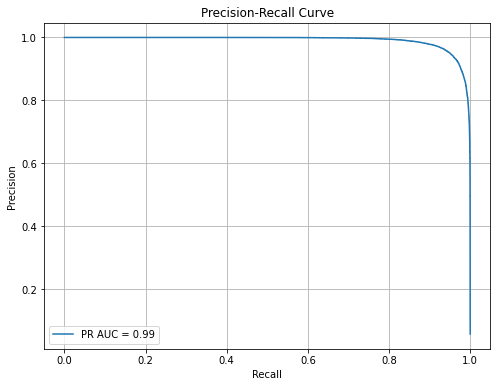

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

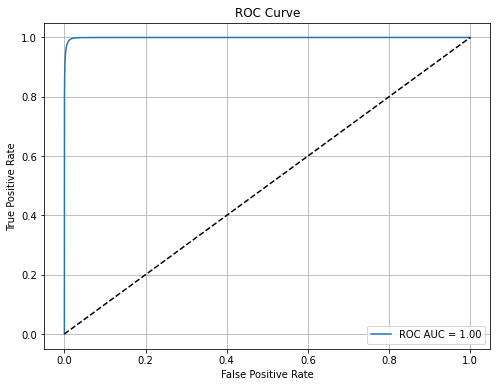

In [74]:
# AUC ROC曲線のプロット
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # 対角線
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()  

### Feature 寄与度を可視化したい

In [80]:
clf.feature_importances_, clf.get_params()

(array([0.05933112, 0.0521264 , 0.06045257, 0.02803679, 0.02302262,
        0.04111389, 0.05476191, 0.03201255, 0.03569432, 0.03138318,
        0.03030661, 0.02780325, 0.05609625, 0.02596359, 0.1112707 ,
        0.13705555, 0.09991029, 0.06835773, 0.02530068]),
 {'bootstrap': True,
  'ccp_alpha': 0.0,
  'class_weight': 'balanced',
  'criterion': 'gini',
  'max_depth': None,
  'max_features': 'sqrt',
  'max_leaf_nodes': None,
  'max_samples': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 10,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'n_estimators': 200,
  'n_jobs': -1,
  'oob_score': False,
  'random_state': 0,
  'verbose': 0,
  'warm_start': False})